# Exercises in Data Transformation and Exploratory Data Analysis

This notebook contains the exercises for the class of February 5, 2025, in the course Data & Things at Roskilde University.

In [112]:
import numpy
import pandas
import matplotlib.pyplot as plot
import seaborn

## Exercise 1

Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 

In [113]:
cinema_data = pandas.read_csv('DK_cinemas.csv', sep=";")
years = cinema_data["Year"].tolist()
cinemas = cinema_data["Cinemas"].tolist()

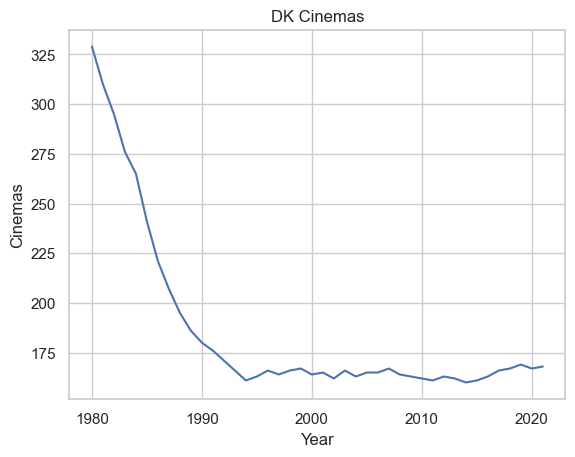

In [114]:
plot.plot(years, cinemas)
plot.xlabel("Year")
plot.ylabel("Cinemas")
plot.title("DK Cinemas")
plot.grid(True)
plot.show()

## Exercise 2

In this exercise, we are going to use the `penguins` dataset from the Seaborn package. The cell below loads the data

In [115]:

# Is already a data_frame
penguins_data = seaborn.load_dataset("penguins")

Based on the `Penguins` dataset, answer the following questions:

1. Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.
2. Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers
3. Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.
4. Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.
5. Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.
6. Visualise how the linear correlation between body mass and flipper length varies between species and sex.

In [116]:
penguins_data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


### 1. Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.

There is no need to not count the penguins with NaN measurements

species
Adelie       152
Chinstrap     68
Gentoo       124


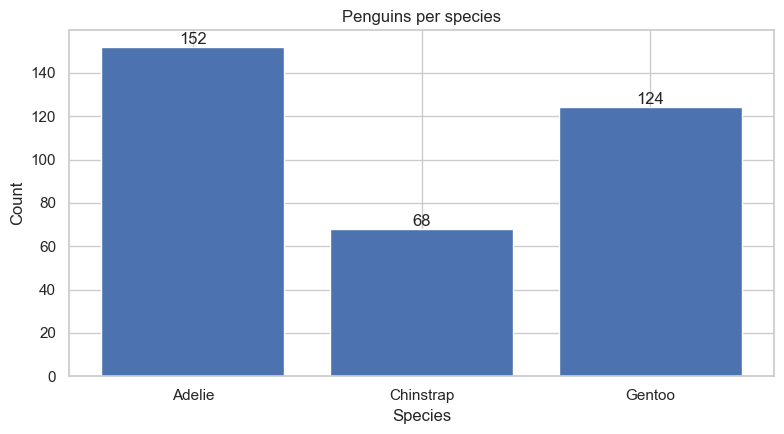

In [117]:

# Calculate counts (supporting numbers)
species_counts = (penguins_data["species"]
    .value_counts()
    .sort_index())

print(species_counts.to_string())

# Bar plot
fig, ax = plot.subplots(figsize=(8, 4.5))
bars = ax.bar(species_counts.index.tolist(), species_counts.values.tolist())

ax.set_title("Penguins per species")
ax.set_xlabel("Species")
ax.set_ylabel("Count")
ax.grid(True, axis="y")
ax.bar_label(bars)  # show counts on the bars

fig.tight_layout()
plot.show()

### 2. Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers

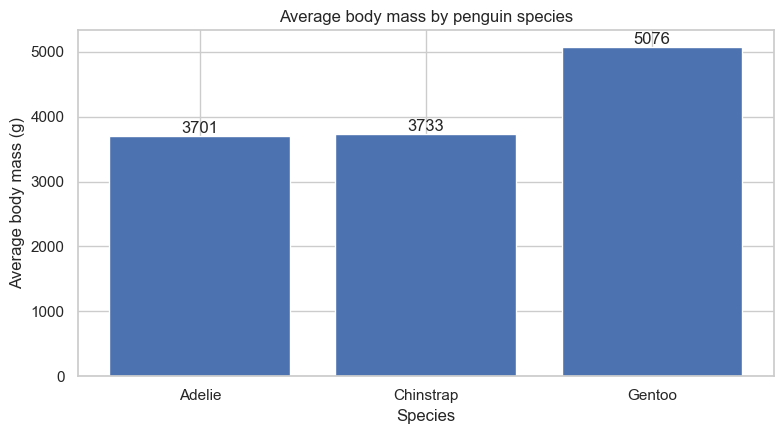

In [118]:
avg_mass = (
    clean_data_frame.groupby("species")["body_mass_g"]
            .mean()
            .sort_index()
)

fig, ax = plot.subplots(figsize=(8, 4.5))
bars = ax.bar(avg_mass.index.tolist(), avg_mass.values.tolist())

ax.set_title("Average body mass by penguin species")
ax.set_xlabel("Species")
ax.set_ylabel("Average body mass (g)")
ax.grid(True, axis="y")
ax.bar_label(bars, fmt="%.0f")  # show averages on bars

fig.tight_layout()
plot.show()

### 3. Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.

           count         mean         std     min     25%     50%     75%  \
species                                                                     
Adelie     151.0  3700.662252  458.566126  2850.0  3350.0  3700.0  4000.0   
Chinstrap   68.0  3733.088235  384.335081  2700.0  3487.5  3700.0  3950.0   
Gentoo     123.0  5076.016260  504.116237  3950.0  4700.0  5000.0  5500.0   

              max  
species            
Adelie     4775.0  
Chinstrap  4800.0  
Gentoo     6300.0  


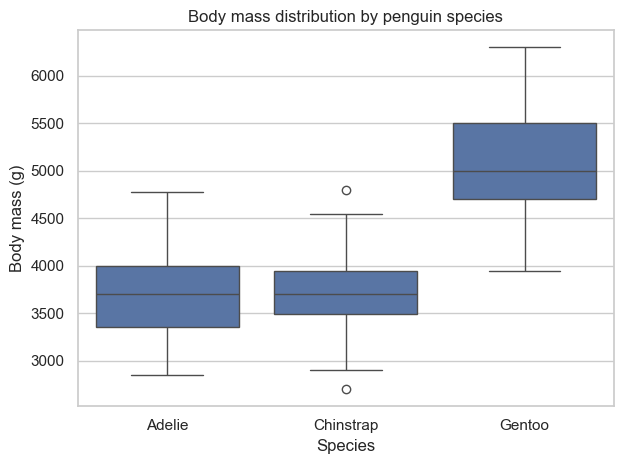

In [119]:
stats = (
    clean_data_frame.groupby("species")["body_mass_g"]
      .describe()
      .loc[:, ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)

print(stats)

# Boxplot
seaborn.set_theme(style="whitegrid")
ax = seaborn.boxplot(data=clean_data_frame, x="species", y="body_mass_g")

ax.set_title("Body mass distribution by penguin species")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")

plot.tight_layout()
plot.show()


### 4. Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.

       body_mass_g  flipper_length_mm
count   342.000000         342.000000
mean   4201.754386         200.915205
std     801.954536          14.061714
min    2700.000000         172.000000
25%    3550.000000         190.000000
50%    4050.000000         197.000000
75%    4750.000000         213.000000
max    6300.000000         231.000000
Pearson correlation (r):  0.8712
Spearman correlation (ρ): 0.8400


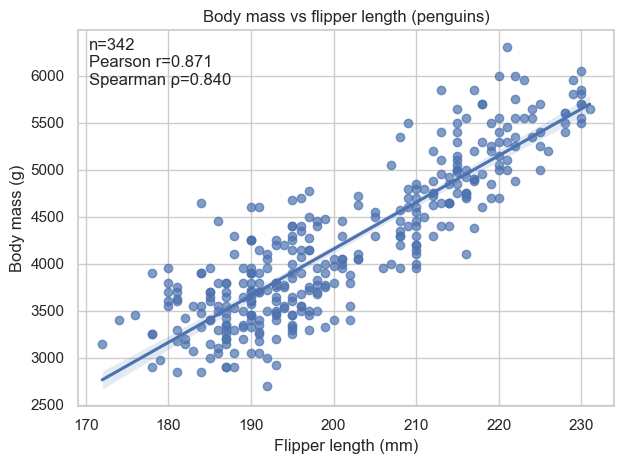

In [120]:
# Support numbers: descriptive stats for both variables
## .loc = labels
## .iloc = integer positions
stats = (
    clean_data_frame[["body_mass_g", "flipper_length_mm"]]
      .describe()
      # “keep all species rows, but only these statistic columns.”
      .loc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)

print(stats)

# Correlation (the key "number" behind the scatterplot)
pearson_corr = clean_data_frame["body_mass_g"].corr(clean_data_frame["flipper_length_mm"], method="pearson")
spearman_corr = clean_data_frame["body_mass_g"].corr(clean_data_frame["flipper_length_mm"], method="spearman")

print(f"Pearson correlation (r):  {pearson_corr:.4f}")
print(f"Spearman correlation (ρ): {spearman_corr:.4f}")

# Scatterplot (+ regression line to visualize correlation)
seaborn.set_theme(style="whitegrid")
ax = seaborn.regplot(
    data=clean_data_frame,
    x="flipper_length_mm",
    y="body_mass_g",
    scatter_kws={"alpha": 0.7}
)

ax.set_title("Body mass vs flipper length (penguins)")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")

# Optional: annotate the plot with correlation numbers
ax.text(
    0.02, 0.98,
    f"n={len(clean_data_frame)}\nPearson r={pearson_corr:.3f}\nSpearman ρ={spearman_corr:.3f}",
    transform=ax.transAxes,
    ha="left", va="top"
)

plot.tight_layout()
plot.show()

### 5. Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.

           metric   species    sex  count        mean        std    min      25%  median      75%    max
   bill_length_mm    Adelie Female   73.0   37.257534   2.028883   32.1   35.900   37.00   38.800   42.2
   bill_length_mm    Adelie   Male   73.0   40.390411   2.277131   34.6   39.000   40.60   41.500   46.0
   bill_length_mm Chinstrap Female   34.0   46.573529   3.108669   40.9   45.425   46.30   47.375   58.0
   bill_length_mm Chinstrap   Male   34.0   51.094118   1.564558   48.5   50.050   50.95   51.975   55.8
   bill_length_mm    Gentoo Female   58.0   45.563793   2.051247   40.9   43.850   45.50   46.875   50.5
   bill_length_mm    Gentoo   Male   61.0   49.473770   2.720594   44.4   48.100   49.50   50.500   59.6
    bill_depth_mm    Adelie Female   73.0   17.621918   0.942993   15.5   17.000   17.60   18.300   20.7
    bill_depth_mm    Adelie   Male   73.0   19.072603   1.018886   17.0   18.500   18.90   19.600   21.5
    bill_depth_mm Chinstrap Female   34.0   17.588235  

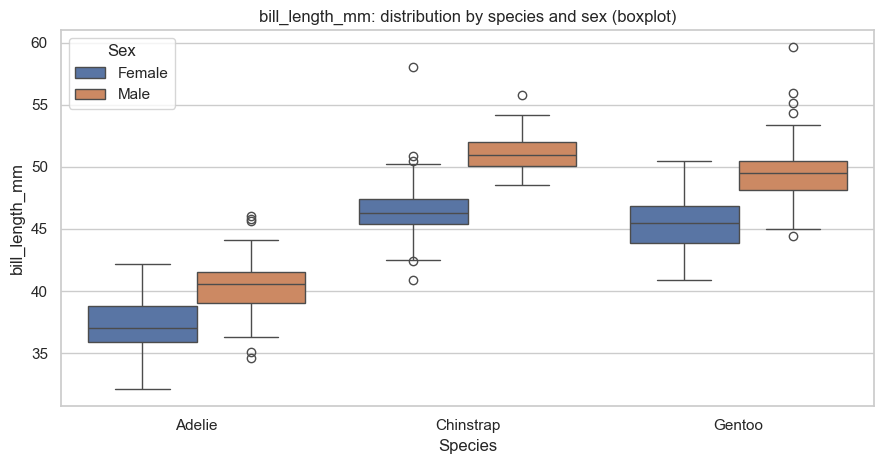

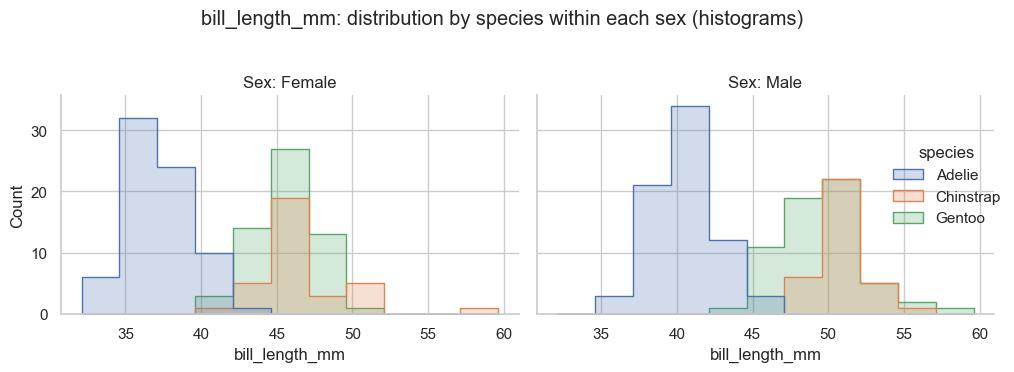

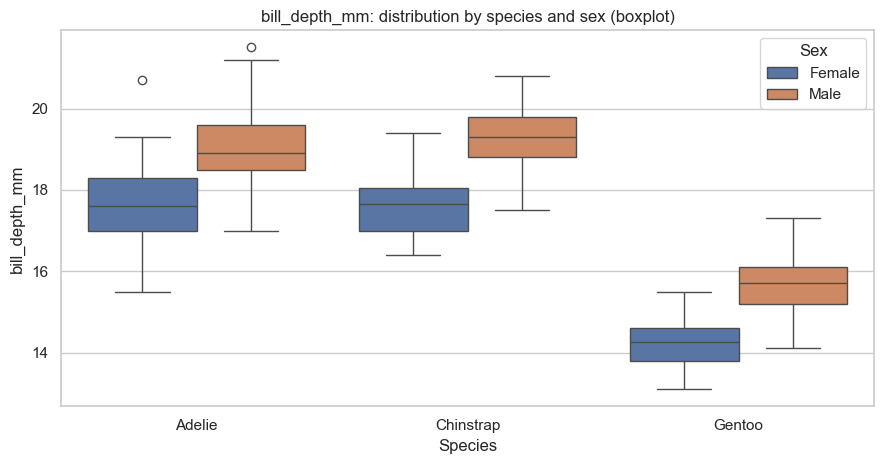

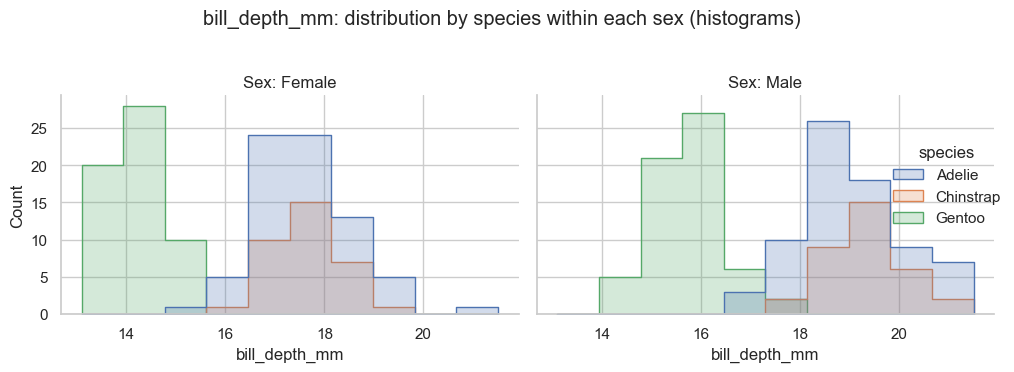

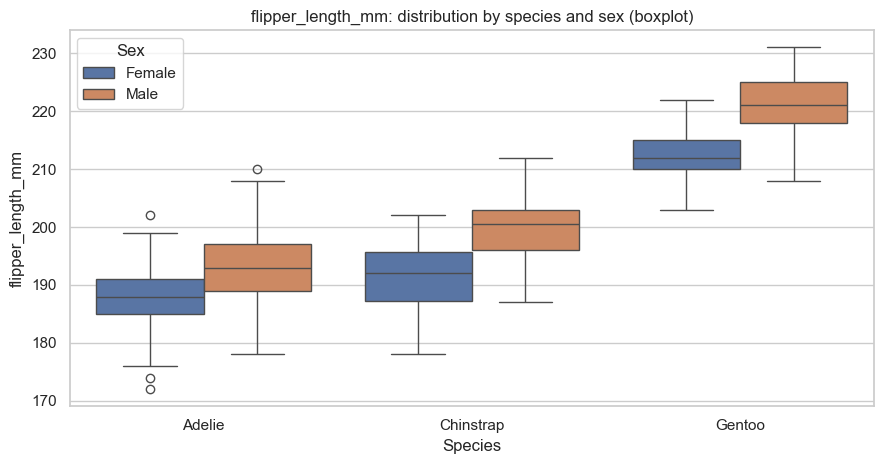

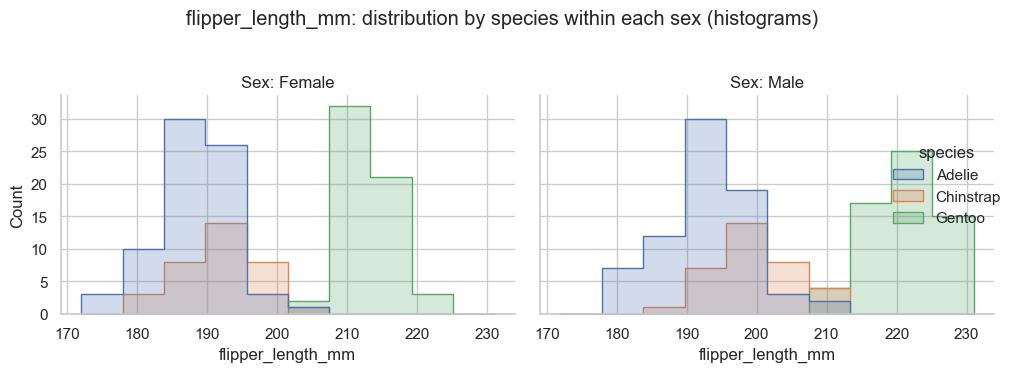

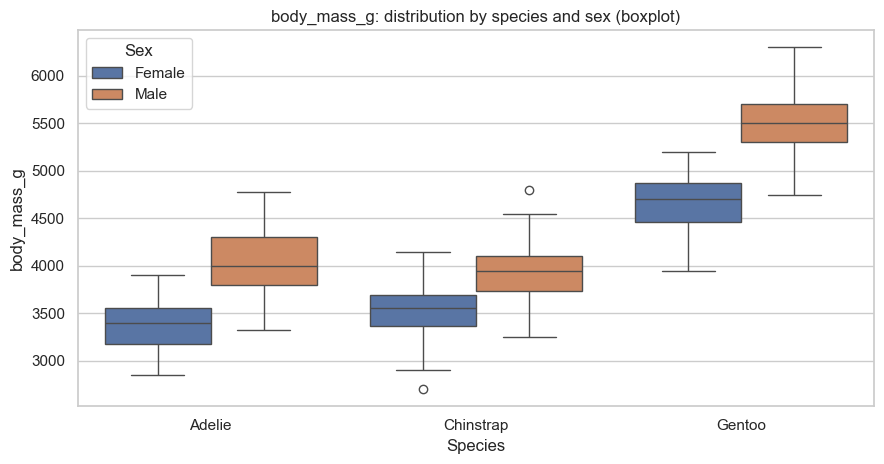

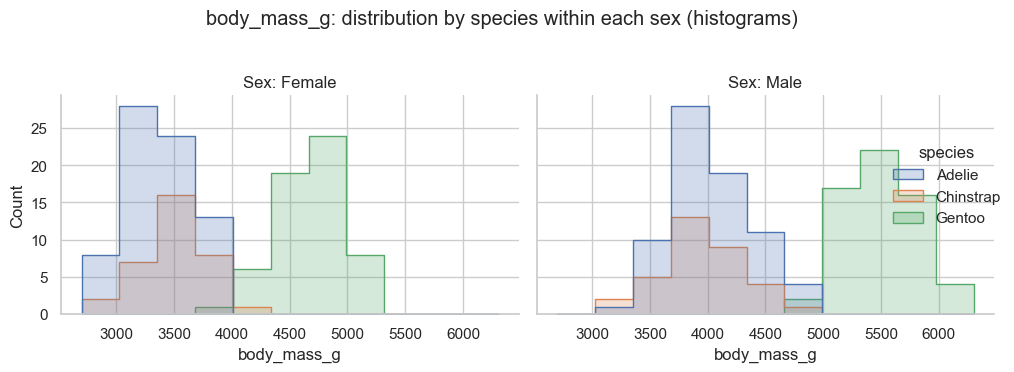

In [121]:
metrics = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# ---------- Support the plots by calculating the numbers ----------
# (Important: we drop NaNs per-metric so each stat/plot uses all available rows for that variable)
summary_tables = []
for m in metrics:
    s = (
        penguins_data.dropna(subset=["species", "sex", m])
          .groupby(["species", "sex"])[m]
          .describe()
          .loc[:, ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
          .rename(columns={"50%": "median"})
          .reset_index()
    )
    s.insert(0, "metric", m)
    summary_tables.append(s)

summary = pandas.concat(summary_tables, ignore_index=True)
print(summary.to_string(index=False))

# ---------- Plots ----------
seaborn.set_theme(style="whitegrid")

species_order = sorted(penguins_data["species"].dropna().unique().tolist())
sex_order = [s for s in ["Female", "Male"] if s in set(penguins_data["sex"].dropna().unique())]

for m in metrics:
    plot_df = penguins_data.dropna(subset=["species", "sex", m]).copy()
    plot_df["species"] = pandas.Categorical(plot_df["species"], categories=species_order, ordered=True)
    plot_df["sex"] = pandas.Categorical(plot_df["sex"], categories=sex_order, ordered=True)

    # 1) Boxplot: distribution by species, split by sex
    fig, ax = plot.subplots(figsize=(9, 4.8))
    seaborn.boxplot(
        data=plot_df,
        x="species",
        y=m,
        hue="sex",
        order=species_order,
        hue_order=sex_order,
        ax=ax
    )
    ax.set_title(f"{m}: distribution by species and sex (boxplot)")
    ax.set_xlabel("Species")
    ax.set_ylabel(m)
    ax.legend(title="Sex", frameon=True)
    ax.grid(True, axis="y")
    fig.tight_layout()
    plot.show()

    # 2) Histogram: facet by sex, overlay species within each sex
    g = seaborn.displot(
        data=plot_df,
        x=m,
        col="sex",
        col_order=sex_order,
        hue="species",
        kind="hist",
        bins="auto",
        element="step",
        stat="count",
        common_norm=False,
        height=3.6,
        aspect=1.25
    )
    g.set_axis_labels(m, "Count")
    g.set_titles(col_template="Sex: {col_name}")
    g.fig.suptitle(f"{m}: distribution by species within each sex (histograms)", y=1.03)
    g.fig.tight_layout()
    plot.show()

### 6. Visualise how the linear correlation between body mass and flipper length varies between species and sex.

/var/folders/l5/q4487tr5709g4879jv7kvkq40000gn/T/ipykernel_20317/1469659947.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(corr_and_fit)


  species    sex    n  pearson_r  spearman_rho     slope    intercept       r2
   Adelie Female 73.0   0.262930      0.244893 12.659084   991.529057 0.069132
   Adelie   Male 73.0   0.360434      0.401107 18.941783   398.886433 0.129913
Chinstrap Female 34.0   0.242150      0.258367 12.007726  1224.901074 0.058637
Chinstrap   Male 34.0   0.664588      0.675582 40.269356 -4111.347531 0.441677
   Gentoo Female 58.0   0.487618      0.526639 35.225169 -2812.894941 0.237771
   Gentoo   Male 61.0   0.330452      0.354693 18.240662  1443.781834 0.109199


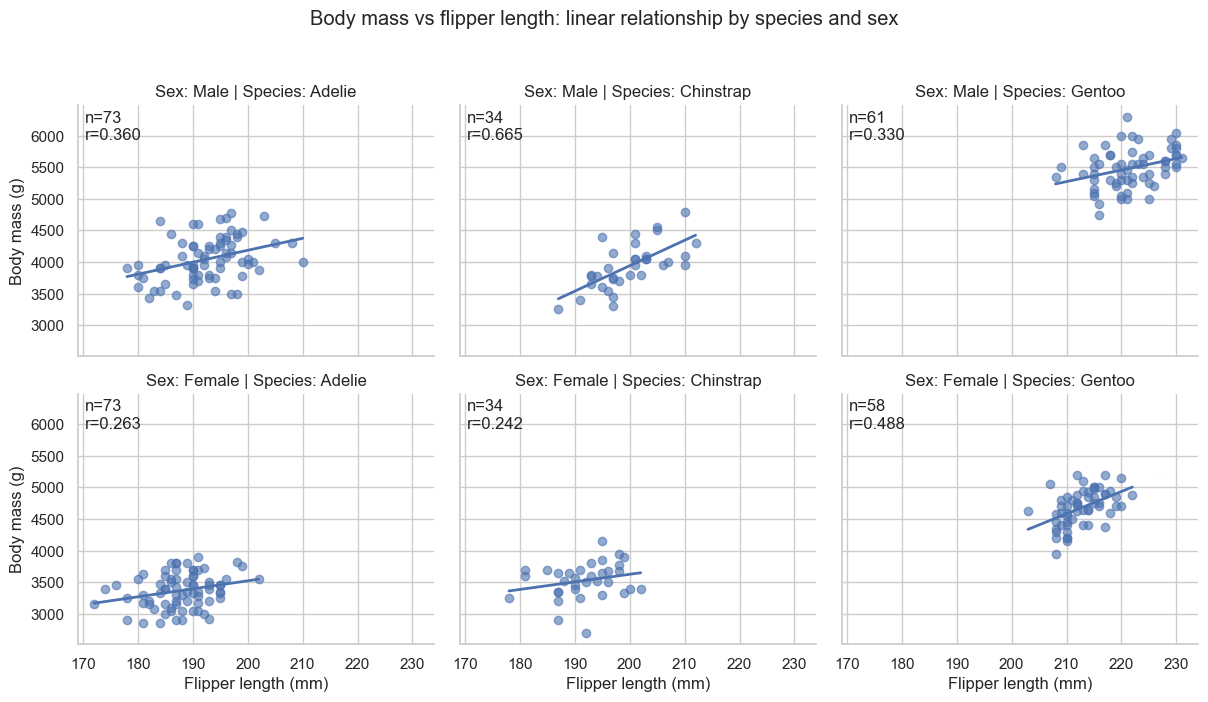

In [126]:
# Clean only what we need
clean_data_frame = penguins_data.dropna(subset=["species", "sex", "body_mass_g", "flipper_length_mm"]).copy()

# ----------------------------
# Support numbers (per species + sex)
# ----------------------------
def corr_and_fit(g: pandas.DataFrame) -> pandas.Series:
    x = g["flipper_length_mm"].to_numpy(dtype=float)
    y = g["body_mass_g"].to_numpy(dtype=float)
    n = len(g)

    if n < 2:
        return pandas.Series(
            {"n": n, "pearson_r": numpy.nan, "spearman_rho": numpy.nan, "slope": numpy.nan, "intercept": numpy.nan, "r2": numpy.nan}
        )

    pearson_r = float(numpy.corrcoef(x, y)[0, 1])
    spearman_rho = float(pandas.Series(x).corr(pandas.Series(y), method="spearman"))

    slope, intercept = numpy.polyfit(x, y, 1)
    y_hat = slope * x + intercept
    ss_res = float(numpy.sum((y - y_hat) ** 2))
    ss_tot = float(numpy.sum((y - numpy.mean(y)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return pandas.Series(
        {"n": n, "pearson_r": pearson_r, "spearman_rho": spearman_rho, "slope": slope, "intercept": intercept, "r2": r2}
    )

corr_table = (
    clean_data_frame
    .groupby(["species", "sex"], dropna=False)
    .apply(corr_and_fit)
    .reset_index()
    .sort_values(["species", "sex"])
)

print(corr_table.to_string(index=False))

# ----------------------------
# Visualisation: correlation varies by species AND sex
# ----------------------------
seaborn.set_theme(style="whitegrid")

g = seaborn.lmplot(
    data=clean_data_frame,
    x="flipper_length_mm",
    y="body_mass_g",
    row="sex",
    col="species",
    height=3.4,
    aspect=1.2,
    scatter_kws={"alpha": 0.6},
    line_kws={"linewidth": 2},
    ci=None
)

g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.set_titles(row_template="Sex: {row_name}", col_template="Species: {col_name}")

# Annotate each facet with n and Pearson r (uses same grouping as the panels)
for (row_val, col_val), ax in g.axes_dict.items():
    sub = clean_data_frame[(clean_data_frame["sex"] == row_val) & (clean_data_frame["species"] == col_val)]
    n = len(sub)
    if n >= 2:
        r = sub["body_mass_g"].corr(sub["flipper_length_mm"], method="pearson")
        ax.text(
            0.02, 0.98,
            f"n={n}\nr={r:.3f}",
            transform=ax.transAxes,
            ha="left", va="top"
        )
    else:
        ax.text(0.02, 0.98, f"n={n}", transform=ax.transAxes, ha="left", va="top")

g.fig.suptitle("Body mass vs flipper length: linear relationship by species and sex", y=1.03)
plot.tight_layout()
plot.show()


## Exercise 3

Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)

In [127]:
from ucimlrepo import fetch_ucirepo 
adult = fetch_ucirepo(id=2) 
X = adult.data.features 
y = adult.data.targets 
X["income"] = y
adult_data = X.copy()

adult_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


## Exercise 4 (Optional)

Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)

## Exercise 5 (Optional)

Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.

In [128]:
from sklearn.datasets import load_diabetes
d_data = load_diabetes(as_frame=True)
diabetes_data = d_data.data
diabetes_data["Target"] = d_data.target

diabetes_data

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0
